## Evaluation of the generator Models  
generator_<model_name>_oneshot_biasbio_results

In [30]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def normalize_label(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = x.replace("\\_", "_")
    x = " ".join(x.split())
    x = x.lower()
    return x


def jsonl_to_df(path, model_name):
    records = load_jsonl(path)

    rows = []
    for r in records:
        rows.append({
            "model": model_name,
            "id": r.get("id"),
            "prediction": r.get("prediction"),
            "ground_truth": r.get("ground_truth"),
            "finish_reason": r.get("finish_reason"),
            "run_id": r.get("run_id"),
            "gender": r.get("metadata", {}).get("gender"),
            "prompt_length": pd.to_numeric(
                r.get("metadata", {}).get("prompt_length"),
                errors="coerce"
            )
        })

    df = pd.DataFrame(rows)

    df["prediction_norm"] = df["prediction"].apply(normalize_label)
    df["ground_truth_norm"] = df["ground_truth"].apply(normalize_label)

    df["correct"] = (
        df["prediction_norm"] == df["ground_truth_norm"]
    ).astype(int)

    return df


paths = {
    "llama8": r"C:\Users\georg\Documents\VScode\Thesis\LLM_judge\project\agregation_methods\generator_llama8_oneshot_BiasBio_results.jsonl",
    "mistral7": r"C:\Users\georg\Documents\VScode\Thesis\LLM_judge\project\agregation_methods\generator_mistral7_oneshot_BiasBio_results.jsonl",
    "qwen7": r"C:\Users\georg\Documents\VScode\Thesis\LLM_judge\project\agregation_methods\generator_qwen7_oneshot_BiasBio_results.jsonl",
}

dfs = []
for model_name, path in paths.items():
    dfs.append(jsonl_to_df(path, model_name))

df_all = pd.concat(dfs, ignore_index=True)

print(df_all.shape)
display(df_all.head())

summary = (
    df_all.groupby("model")
    .agg(
        total_rows=("id", "count"),
        unique_ids=("id", "nunique"),
        accuracy=("correct", "mean"),
        num_classes=("ground_truth_norm", "nunique"),
    )
    .sort_values("accuracy", ascending=False)
)

display(summary)

(6000, 11)


,model,id,prediction,ground_truth,finish_reason,run_id,gender,prompt_length,prediction_norm,ground_truth_norm,correct
0,llama8,1,photographer,photographer,stop,0,male,167,photographer,photographer,1
1,llama8,2,filmmaker,filmmaker,stop,0,female,115,filmmaker,filmmaker,1
2,llama8,3,filmmaker,filmmaker,stop,0,male,147,filmmaker,filmmaker,1
3,llama8,4,physician,physician,stop,0,female,47,physician,physician,1
4,llama8,5,composer,composer,stop,0,female,128,composer,composer,1


,total_rows,unique_ids,accuracy,num_classes
model,,,,
llama8,2000,2000,0.7355,28
qwen7,2000,2000,0.7235,28
mistral7,2000,2000,0.6715,28


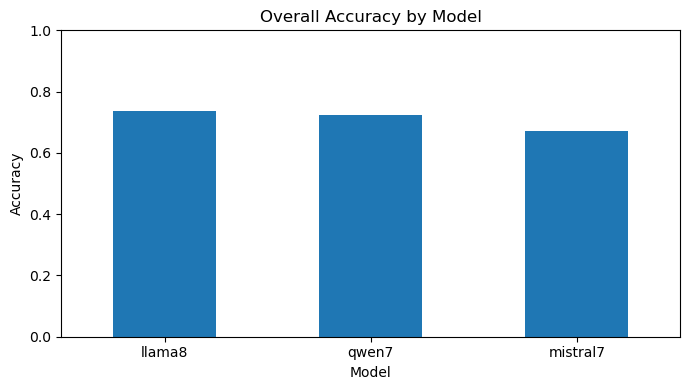

,accuracy
model,
llama8,0.7355
qwen7,0.7235
mistral7,0.6715


In [31]:
acc_by_model = (
    df_all.groupby("model")["correct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
acc_by_model.plot(kind="bar")
plt.ylim(0, 1)
plt.title("Overall Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(acc_by_model.to_frame("accuracy"))

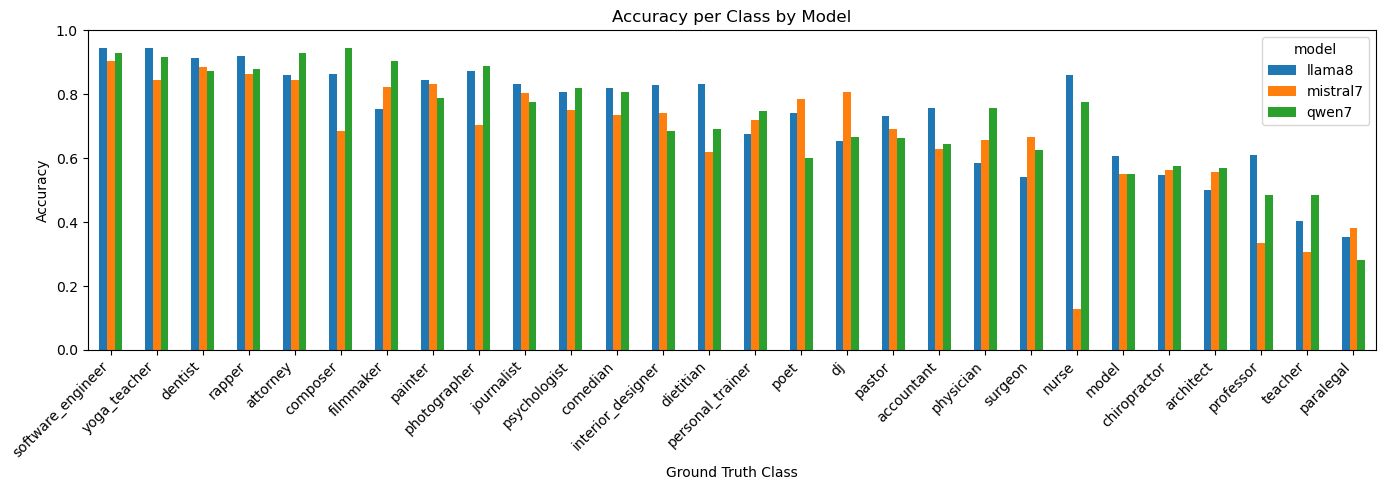

model,llama8,mistral7,qwen7
ground_truth,,,
software_engineer,0.944444,0.902778,0.930556
yoga_teacher,0.943662,0.845070,0.915493
dentist,0.914286,0.885714,0.871429
rapper,0.918919,0.864865,0.878378
attorney,0.859155,0.845070,0.929577
composer,0.863014,0.684932,0.945205
filmmaker,0.753425,0.821918,0.904110
painter,0.845070,0.830986,0.788732
photographer,0.873239,0.704225,0.887324


In [ ]:
# Accuracy by

acc_per_class = (
    df_all.groupby(["ground_truth", "model"])["correct"]
    .mean()
    .reset_index()
)

pivot_acc_class = acc_per_class.pivot(
    index="ground_truth",
    columns="model",
    values="correct"
)

pivot_acc_class = pivot_acc_class.loc[
    pivot_acc_class.mean(axis=1).sort_values(ascending=False).index
]

pivot_acc_class.plot(kind="bar", figsize=(14, 5))
plt.ylim(0, 1)
plt.title("Accuracy per Class by Model")
plt.xlabel("Ground Truth Class")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(pivot_acc_class)

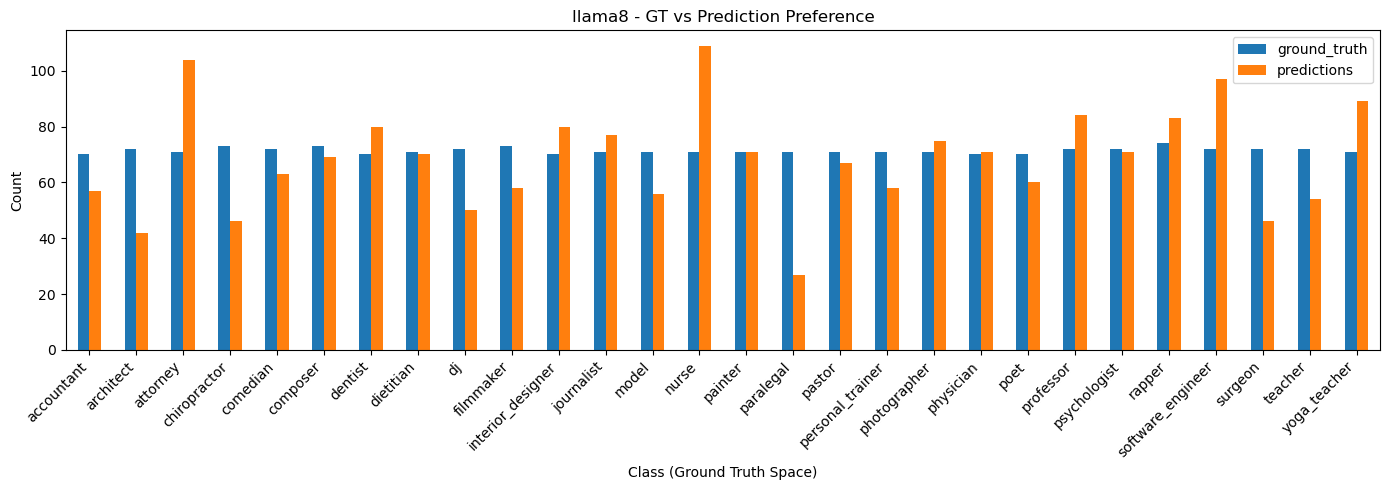

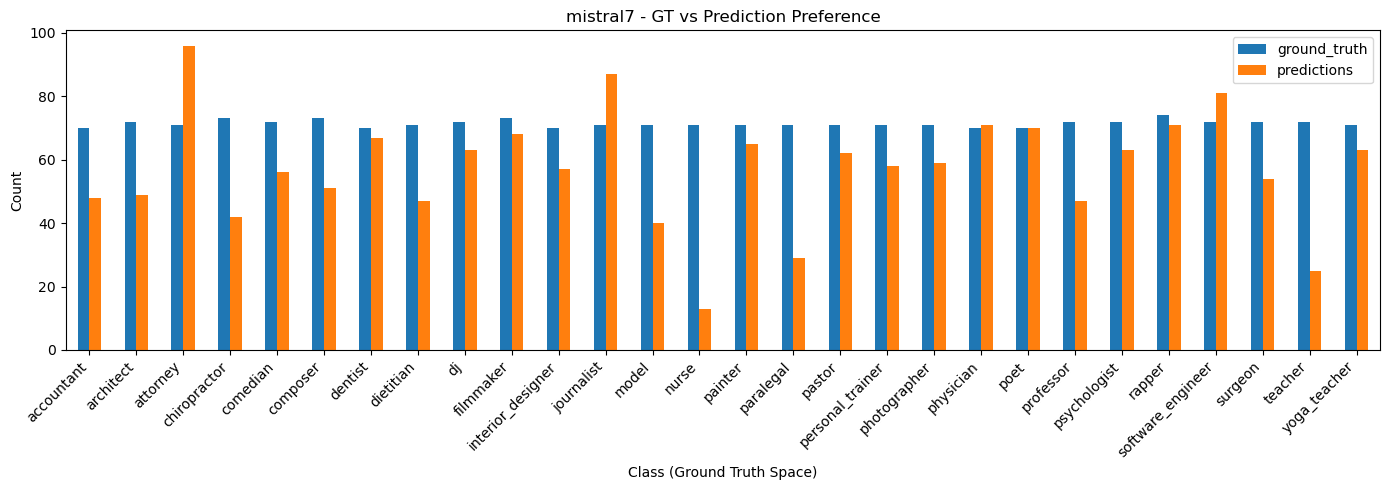

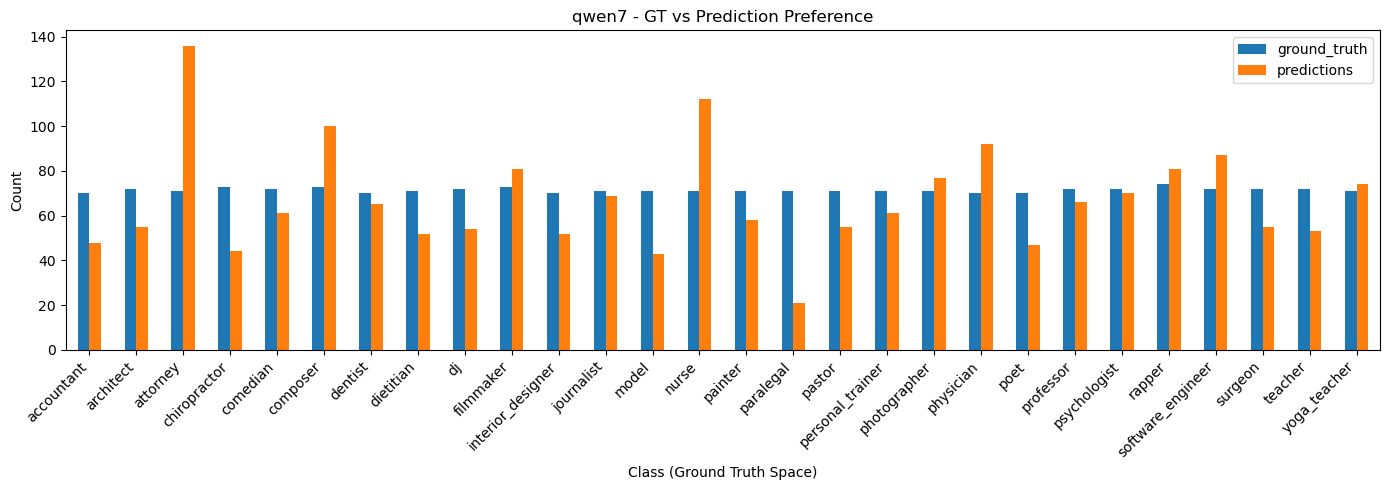

In [41]:
for model_name in df_all["model"].unique():
    temp = df_all[df_all["model"] == model_name]

    labels = sorted(temp["ground_truth_norm"].unique())

    # Ground truth distribution
    gt_counts = temp["ground_truth_norm"].value_counts().reindex(labels, fill_value=0)

    # Prediction preference (mapped to same label space)
    pred_counts = temp["prediction_norm"].value_counts().reindex(labels, fill_value=0)

    df_plot = pd.DataFrame({
        "ground_truth": gt_counts,
        "predictions": pred_counts
    })

    df_plot.plot(kind="bar", figsize=(14,5))

    plt.title(f"{model_name} - GT vs Prediction Preference")
    plt.xlabel("Class (Ground Truth Space)")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

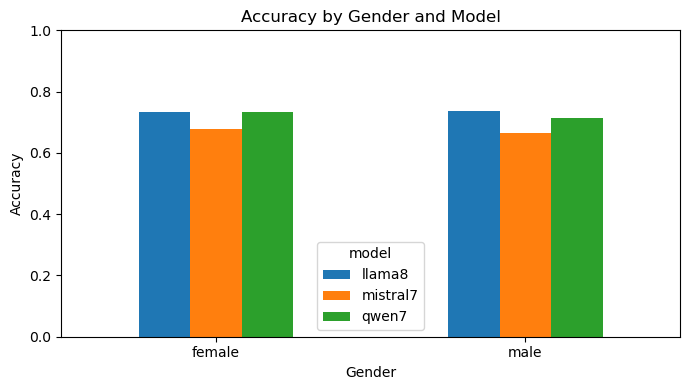

model,llama8,mistral7,qwen7
gender,,,
female,0.734064,0.678287,0.732072
male,0.736948,0.664659,0.714859


In [35]:
#Accurasy by gender

acc_by_gender = (
    df_all.groupby(["gender", "model"])["correct"]
    .mean()
    .reset_index()
)

pivot_gender = acc_by_gender.pivot(
    index="gender",
    columns="model",
    values="correct"
)

pivot_gender.plot(kind="bar", figsize=(7, 4))
plt.ylim(0, 1)
plt.title("Accuracy by Gender and Model")
plt.xlabel("Gender")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(pivot_gender)

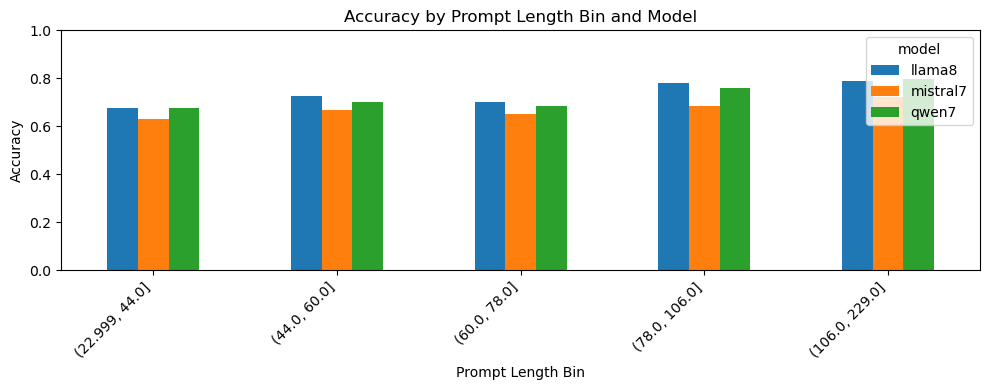

model,llama8,mistral7,qwen7
prompt_bin,,,
"(22.999, 44.0]",0.677340,0.630542,0.674877
"(44.0, 60.0]",0.727500,0.667500,0.702500
"(60.0, 78.0]",0.703242,0.653367,0.683292
"(78.0, 106.0]",0.781955,0.686717,0.761905
"(106.0, 229.0]",0.789340,0.720812,0.796954


In [37]:
temp = df_all.dropna(subset=["prompt_length"]).copy()
temp["prompt_bin"] = pd.qcut(temp["prompt_length"], q=5, duplicates="drop")

acc_by_prompt_bin = (
    temp.groupby(["prompt_bin", "model"], observed=False)["correct"]
    .mean()
    .reset_index()
)

pivot_prompt = acc_by_prompt_bin.pivot(
    index="prompt_bin",
    columns="model",
    values="correct"
)

pivot_prompt.plot(kind="bar", figsize=(10, 4))
plt.ylim(0, 1)
plt.title("Accuracy by Prompt Length Bin and Model")
plt.xlabel("Prompt Length Bin")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(pivot_prompt)

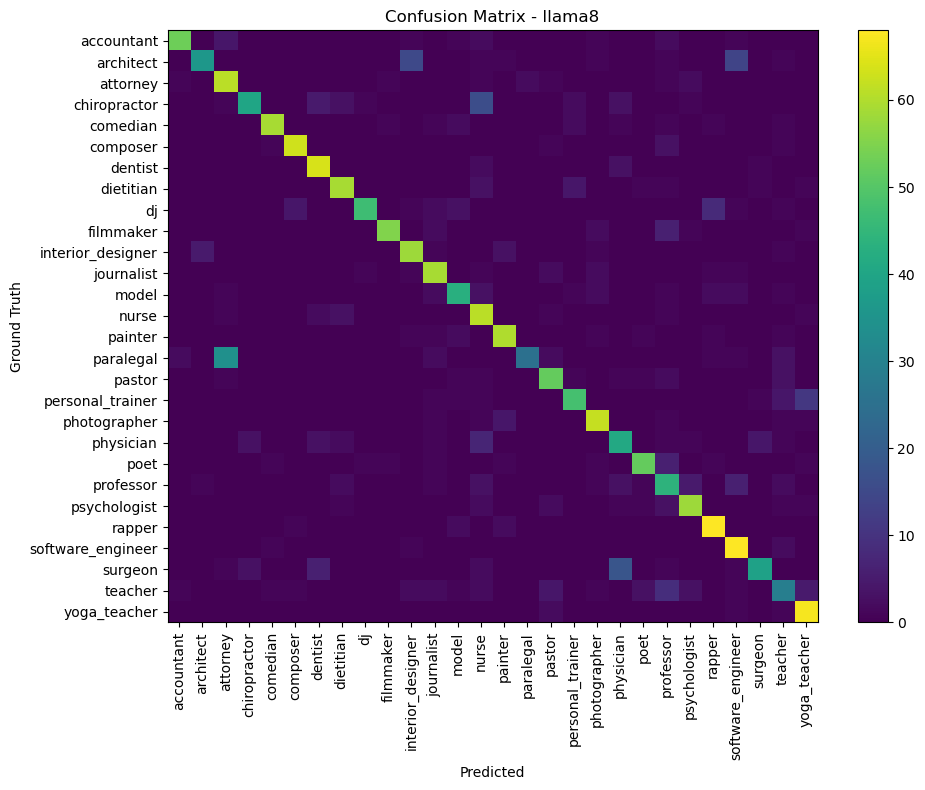

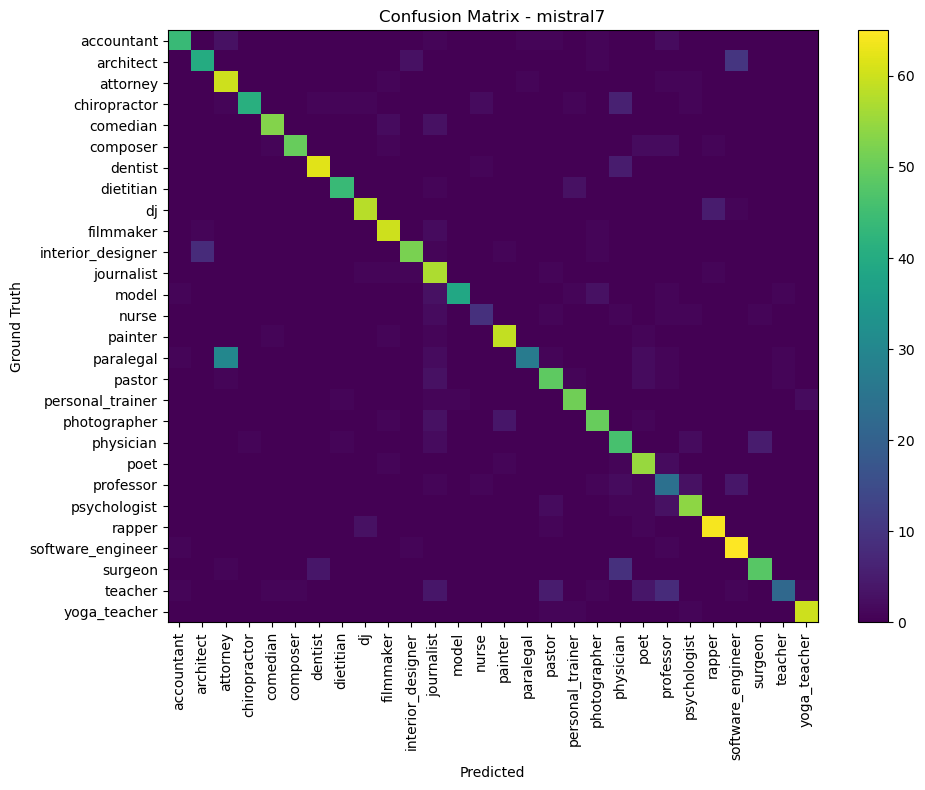

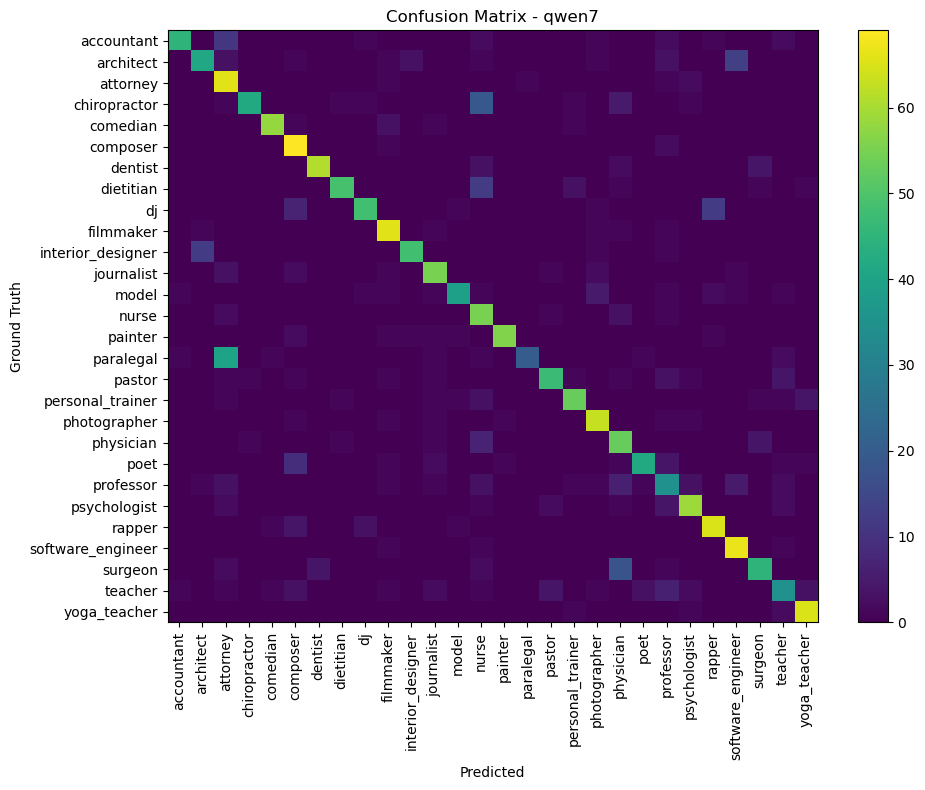

In [40]:
for model_name in df_all["model"].unique():
    temp = df_all[df_all["model"] == model_name].copy()
    labels = sorted(temp["ground_truth_norm"].dropna().unique())


    cm = confusion_matrix(
    temp["ground_truth_norm"],
    temp["prediction_norm"],
    labels=labels
)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, aspect="auto")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [39]:
comparison = (
    df_all.groupby("model")
    .agg(
        accuracy=("correct", "mean"),
        avg_prompt_length=("prompt_length", "mean"),
        num_samples=("id", "count"),
        num_unique_ids=("id", "nunique")
    )
    .sort_values("accuracy", ascending=False)
)

display(comparison.round(4))

,accuracy,avg_prompt_length,num_samples,num_unique_ids
model,,,,
llama8,0.7355,76.4685,2000,2000
qwen7,0.7235,76.4685,2000,2000
mistral7,0.6715,76.4685,2000,2000


## Auto agreement
judge_<model_name>_generator_<model_name>_oneshot_BiasBio_results